# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [1]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

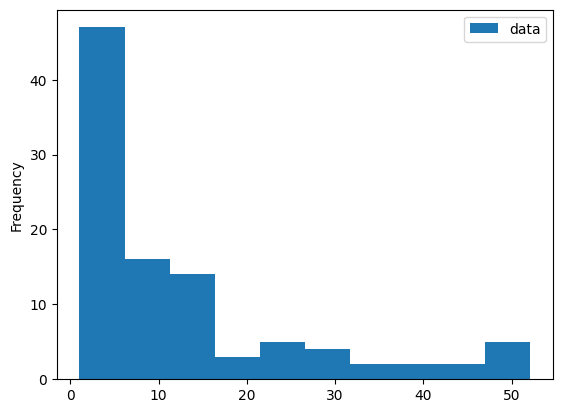

In [2]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

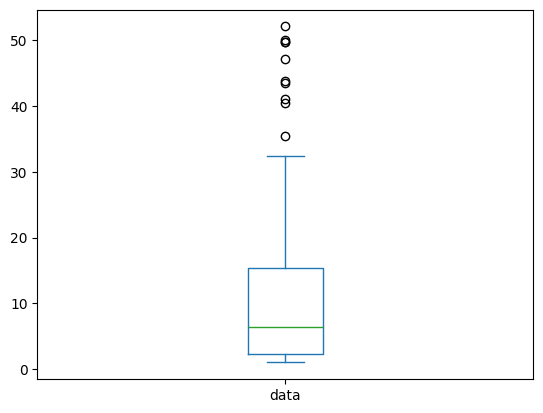

In [3]:
df.plot.box()

In the histogram, most drug prices cost between $0–5. The distribution drops off quickly, with very few drugs above $30. In the box plot, The median price (green line) is around $6, the middle 50% of drugs cost between roughly $2–15 (the box), and the top whisker extends to about $32. 

The histogram is better for seeing the overall shape of the distribution (that most drugs are cheap), but for specifically highlighting expensive drugs in context, the boxplot is a better alternative.

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [4]:
df22 = pd.read_csv('Hospital_Provider_Cost_Report_2022.csv')
df23 = pd.read_csv('Hospital_Provider_Cost_Report_2023_updated.csv')

df = pd.concat([df22, df23], ignore_index=True)

df.to_csv('Hospital_Provider_Cost_Report_2022-2023.csv', index=False)

In [5]:
df.head()

,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code,Zip Code,County,Medicare CBSA Number,Rural Versus Urban,...,Net Income from Service to Patients,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges
0,717629,344028,STRATEGIC BEHAVIORAL CENTER - GARNER,3200 WATERFIELD ROAD,GARNER,NC,27529-7727,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,717969,180078,PAUL B. HALL REGIONAL MEDICAL CENTER,PAUL B. HALL REGIONAL MEDICAL CENTE,PAINTSVILLE,KY,41240,JOHNSON,99918.0,R,...,634470.0,2151392.0,2785862.0,15.0,2785847.0,0.074617,1114125.0,26708472.0,NaN,NaN
2,719460,520210,MARSHFIELD MEDICAL CENTER-EAU CLAIRE,2116 CRAIG ROAD,EAU CLAIRE,WI,54701,NaN,20740.0,U,...,-4259661.0,845990.0,-3413671.0,151877.0,-3565548.0,0.451411,14333809.0,18797586.0,NaN,NaN
3,719475,63037,COBALT REHAB HOSP WESTMINSTER,6500 WEST 104TH AVE,WESTMINSTER,CO,80020,NaN,79740.0,U,...,-1980346.0,NaN,-1980346.0,NaN,-1980346.0,NaN,NaN,NaN,NaN,NaN
4,721379,340123,AMERICAN HEALTHCARE SYSTEMS,373 NORTH FAYETTEVILLE STREET,ASHEBORO,NC,27204-,RANDOLPH,24660.0,U,...,-5248749.0,-6661015.0,-11909764.0,NaN,-11909764.0,0.160752,1724073.0,6249901.0,NaN,NaN


In [6]:
df.describe()

,rpt_rec_num,Provider CCN,Medicare CBSA Number,Provider Type,Type of Control,FTE - Employees on Payroll,Number of Interns and Residents (FTE),Total Days Title V,Total Days Title XVIII,Total Days Title XIX,...,Net Income from Service to Patients,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges
count,12167.000000,12167.000000,12002.000000,12167.000000,12167.000000,11908.000000,3022.000000,261.000000,11833.000000,10107.000000,...,1.199800e+04,1.155000e+04,1.198800e+04,3.505000e+03,1.198800e+04,9213.000000,8.763000e+03,8.733000e+03,1.938000e+03,1.968000e+03
mean,769699.165037,269848.907948,52973.052741,1.732309,4.178762,1075.708420,94.047306,2438.015326,7413.359757,3361.950134,...,-1.140968e+07,2.517214e+07,1.283324e+07,5.257874e+06,1.129596e+07,1.282356,3.260628e+07,1.998714e+08,7.437635e+05,5.030483e+06
std,19112.030029,161022.022161,34000.697007,1.490480,3.197409,10078.502812,169.552177,5552.902681,11968.101445,8091.885707,...,1.376373e+08,1.068688e+08,1.185017e+08,5.060960e+07,1.179878e+08,50.122962,9.043067e+07,4.441838e+08,3.146574e+06,2.938502e+07
min,717629.000000,10001.000000,10180.000000,1.000000,1.000000,0.050000,0.000000,1.000000,1.000000,1.000000,...,-3.979088e+09,-1.693180e+09,-3.955820e+09,-1.234801e+09,-3.955820e+09,0.000000,-2.089892e+07,1.000000e+00,-3.102300e+04,7.200000e+01
25%,755575.500000,140155.000000,26420.000000,1.000000,2.000000,129.080000,8.315000,132.000000,943.000000,112.000000,...,-1.150066e+07,6.680748e+05,-2.339160e+06,-2.000000e+00,-2.697832e+06,0.187977,2.792159e+06,1.103749e+07,1.881025e+04,1.094872e+05
50%,771122.000000,260011.000000,39150.000000,1.000000,2.000000,288.020000,28.340000,849.000000,2695.000000,662.000000,...,-1.679960e+06,3.079538e+06,1.552584e+06,4.932400e+04,1.295440e+06,0.279829,9.215692e+06,5.236590e+07,7.916200e+04,5.300605e+05
75%,786039.000000,393045.500000,99916.000000,1.000000,5.000000,906.312500,91.682500,2565.000000,9019.000000,2997.500000,...,3.830926e+06,1.193693e+07,1.094022e+07,1.518571e+06,9.815405e+06,0.470689,2.856011e+07,1.969878e+08,3.116900e+05,2.160627e+06
max,807303.000000,713029.000000,99966.000000,12.000000,13.000000,987647.000000,1968.000000,59573.000000,208248.000000,183050.000000,...,7.864650e+09,2.658138e+09,7.903916e+09,7.197225e+08,7.919570e+09,3636.891704,3.300915e+09,9.319141e+09,4.598930e+07,8.917134e+08


Re-cleaning data since i combined added 2022 data 

In [7]:
df.duplicated().sum()

0

In [8]:

def show_null_counts_features(df):
    count_nulls = df.isnull().sum()
    df_nulls = (df.isnull().mean() * 100).round(2)
    feature_types = df.dtypes.apply(
        lambda x: "Numeric" if pd.api.types.is_numeric_dtype(x) else "Categorical"
    )
    missing_data = pd.DataFrame({
        "Feature": count_nulls[count_nulls > 0].index,
        "# Null Values": count_nulls[count_nulls > 0].values,
        "Null %": df_nulls[count_nulls > 0].values,
        "Type": feature_types[count_nulls > 0].values
    }).sort_values(by="Null %", ascending=False)
    
    print(f"\nThe dataset contains {len(df):,} samples.\n")
    if len(missing_data) == 0:
        print("There are no null values in the dataset!")
        return
    
    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 200)
    pd.set_option("display.max_colwidth", None)
    missing_data = missing_data.reset_index(drop=True)
    missing_data["Null %"] = missing_data["Null %"].map(lambda x: f"{x:.2f}%")
    print(missing_data.to_string(index=False))

show_null_counts_features(df)


The dataset contains 12,167 samples.

                                                                Feature  # Null Values  Null %        Type
                                        Outlier Payments For Discharges          12167 100.00%     Numeric
                                DRG Amounts Other Than Outlier Payments          12167 100.00%     Numeric
                          Hospital Total Days Title V For Adults & Peds          11927  98.03%     Numeric
                    Hospital Total Discharges Title V For Adults & Peds          11919  97.96%     Numeric
                                               Total Discharges Title V          11919  97.96%     Numeric
                                                     Total Days Title V          11906  97.85%     Numeric
                                                       Notes Receivable          11682  96.01%     Numeric
                                                        Unsecured Loans          11550  94.93%     Numeri

In [9]:
#Drop columns that are 100% null
empty_cols = df.columns[df.isna().mean() == 1.0]
df_clean = df.drop(columns=empty_cols)
print(f"Dropped {len(empty_cols)} fully-empty columns: {empty_cols.tolist()}")

#Separate feature types 
categorical_features = df_clean.select_dtypes(exclude=["number"]).columns.tolist()
numeric_features = df_clean.select_dtypes(include=["number"]).columns.tolist()

# Exclude ID-like columns from imputation
exclude_numeric = ["rpt_rec_num", "Provider CCN", "Medicare CBSA Number"]
numeric_features = [c for c in numeric_features if c not in exclude_numeric]

# Impute: median for numeric, most_frequent for categorical 
df_imputed = df_clean.copy()

num_imputer = SimpleImputer(strategy="median")
df_imputed[numeric_features] = num_imputer.fit_transform(df_imputed[numeric_features])

cat_imputer = SimpleImputer(strategy="most_frequent")
df_imputed[categorical_features] = cat_imputer.fit_transform(df_imputed[categorical_features])

# Drop rows where Medicare CBSA Number is still null
df_imputed = df_imputed.dropna(subset=["Medicare CBSA Number"]).copy()

#Verify no nulls remain 
show_null_counts_features(df_imputed)

Dropped 2 fully-empty columns: ['DRG Amounts Other Than Outlier Payments', 'Outlier Payments For Discharges']

The dataset contains 12,002 samples.

There are no null values in the dataset!


In [10]:
df_imputed.describe()

,rpt_rec_num,Provider CCN,Medicare CBSA Number,Provider Type,Type of Control,FTE - Employees on Payroll,Number of Interns and Residents (FTE),Total Days Title V,Total Days Title XVIII,Total Days Title XIX,Total Days (V + XVIII + XIX + Unknown),Number of Beds,Total Bed Days Available,Total Discharges Title V,Total Discharges Title XVIII,Total Discharges Title XIX,Total Discharges (V + XVIII + XIX + Unknown),Number of Beds + Total for all Subproviders,Hospital Total Days Title V For Adults & Peds,Hospital Total Days Title XVIII For Adults & Peds,Hospital Total Days Title XIX For Adults & Peds,Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds,Hospital Number of Beds For Adults & Peds,Hospital Total Bed Days Available For Adults & Peds,Hospital Total Discharges Title V For Adults & Peds,Hospital Total Discharges Title XVIII For Adults & Peds,Hospital Total Discharges Title XIX For Adults & Peds,Hospital Total Discharges (V + XVIII + XIX + Unknown) For Adults & Peds,Cost of Charity Care,Total Bad Debt Expense,Cost of Uncompensated Care,Total Unreimbursed and Uncompensated Care,Total Salaries From Worksheet A,Overhead Non-Salary Costs,Depreciation Cost,Total Costs,Inpatient Total Charges,Outpatient Total Charges,Combined Outpatient + Inpatient Total Charges,Wage-Related Costs (Core),Wage-Related Costs (RHC/FQHC),Total Salaries (adjusted),Contract Labor: Direct Patient Care,Wage Related Costs for Part - A Teaching Physicians,Wage Related Costs for Interns and Residents,Cash on Hand and in Banks,Temporary Investments,Notes Receivable,Accounts Receivable,Less: Allowances for Uncollectible Notes and Accounts Receivable,Inventory,Prepaid Expenses,Other Current Assets,Total Current Assets,Land,Land Improvements,Buildings,Leasehold Improvements,Fixed Equipment,Major Movable Equipment,Minor Equipment Depreciable,Health Information Technology Designated Assets,Total Fixed Assets,Investments,Other Assets,Total Other Assets,Total Assets,Accounts Payable,"Salaries, Wages, and Fees Payable",Payroll Taxes Payable,Notes and Loans Payable (Short Term),Deferred Income,Other Current Liabilities,Total Current Liabilities,Mortgage Payable,Notes Payable,Unsecured Loans,Other Long Term Liabilities,Total Long Term Liabilities,Total Liabilities,General Fund Balance,Total Fund Balances,Total Liabilities and Fund Balances,DRG Amounts Before October 1,DRG Amounts After October 1,Disproportionate Share Adjustment,Allowable DSH Percentage,Managed Care Simulated Payments,Total IME Payment,Inpatient Revenue,Outpatient Revenue,Total Patient Revenue,Less Contractual Allowance and Discounts on Patients' Accounts,Net Patient Revenue,Less Total Operating Expense,Net Income from Service to Patients,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges
count,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,1.200200e+04,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,12002.000000,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.200200e+04,1.20020

**Mapping the categorial codes properly**

In [11]:
control_map = {
    1.0: 'Voluntary Nonprofit',   # Church
    2.0: 'Voluntary Nonprofit',   # Other nonprofit
    3.0: 'Proprietary',           # Individual
    4.0: 'Proprietary',           # Corporation
    5.0: 'Proprietary',           # Partnership
    6.0: 'Proprietary',           # Other
    7.0: 'Government',            # Federal
    8.0: 'Government',            # City-County
    9.0: 'Government',            # County
    10.0: 'Government',           # State
    11.0: 'Government',           # Hospital District
    12.0: 'Government',           # City
    13.0: 'Government',           # Other
}

df_imputed['Control Type'] = df_imputed['Type of Control'].map(control_map)

facility_map = {
    'STH':   'Short-Term Hospital',
    'CAH':   'Critical Access Hospital',
    'PH':    'Psychiatric Hospital',
    'RH':    'Rehabilitation Hospital',
    'LTCH':  'Long-Term Care Hospital',
    'CH':    'Childrens Hospital',
    'ORD':   'ORD Demonstration Hospital',
    'RNMHC': 'Religious Non-Medical Institution'
}

df_imputed['Facility Type Label'] = df_imputed['CCN Facility Type'].map(facility_map)

print(f'Ready: {len(df_imputed):,} hospitals')

Ready: 12,002 hospitals


In [12]:
cols = [
    ('Number of Beds',             1,    'Beds'),
    ('Net Income',                 1e6,  '$ Millions'),
    ('Total Costs',                1e6,  '$ Millions'),
    ('Net Revenue from Medicaid',  1e6,  '$ Millions'),
]

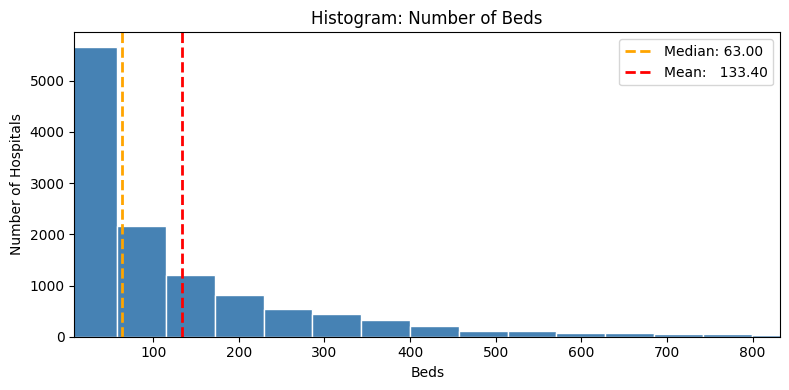

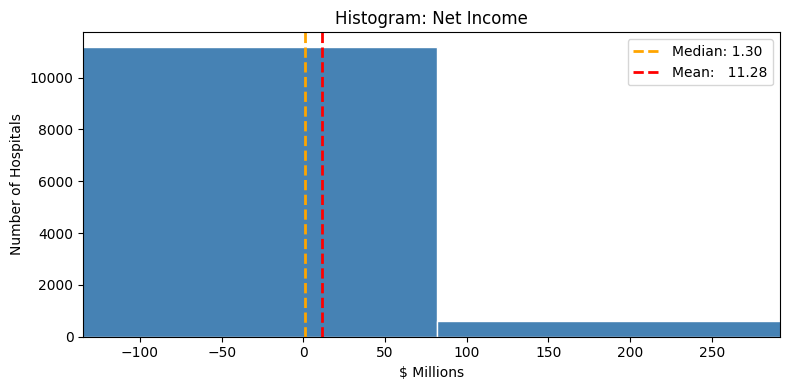

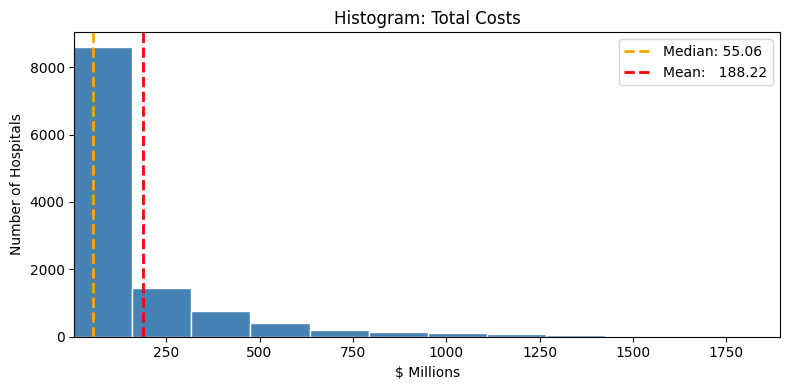

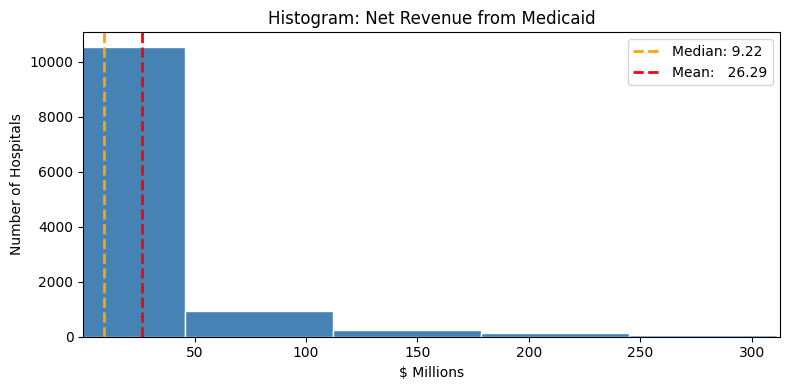

In [13]:
for col, div, unit in cols:
    d = df_imputed[col] / div

    xlim = (d.quantile(0.01), d.quantile(0.99))
    pct_clipped = ((d < xlim[0]) | (d > xlim[1])).mean() * 100

    plt.figure(figsize=(8, 4))
    plt.hist(d, bins=50, color='steelblue', edgecolor='white')
    plt.axvline(d.median(), color='orange', linewidth=2, linestyle='--',
                label=f'Median: {d.median():.2f}')
    plt.axvline(d.mean(),   color='red',    linewidth=2, linestyle='--',
                label=f'Mean:   {d.mean():.2f}')
    plt.xlim(xlim)
    plt.title(f'Histogram: {col}')
    plt.xlabel(unit)
    plt.ylabel('Number of Hospitals')
    plt.legend()
    plt.tight_layout()
    plt.show()

**Financial variables such as Net Income, Total Costs, and Medicaid Revenue are heavily skewed, which is typical in healthcare finance where a small number of large hospitals account for a disproportionate share of total dollars.**

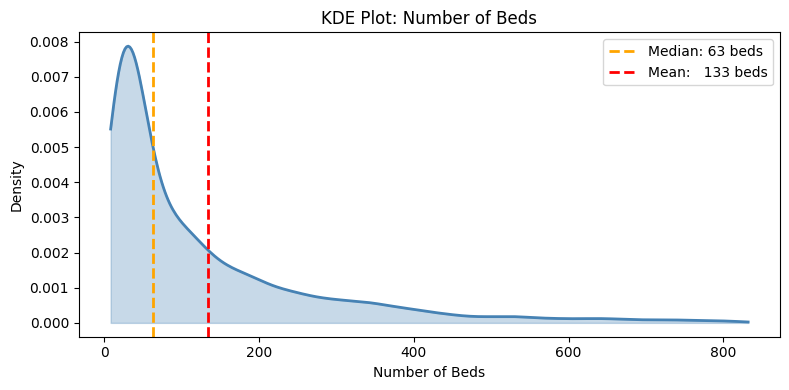

In [14]:
from scipy.stats import gaussian_kde

beds = df_imputed['Number of Beds']
p1, p99 = beds.quantile(0.01), beds.quantile(0.99)
beds_clipped = beds[beds.between(p1, p99)]

xs = np.linspace(p1, p99, 400)
kde = gaussian_kde(beds_clipped)

plt.figure(figsize=(8, 4))
plt.plot(xs, kde(xs), color='steelblue', linewidth=2)
plt.fill_between(xs, kde(xs), alpha=0.3, color='steelblue')
plt.axvline(beds.median(), color='orange', linewidth=2, linestyle='--',
            label=f'Median: {beds.median():.0f} beds')
plt.axvline(beds.mean(),   color='red',    linewidth=2, linestyle='--',
            label=f'Mean:   {beds.mean():.0f} beds')
plt.title('KDE Plot: Number of Beds')
plt.xlabel('Number of Beds')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

**Most hospitals have a moderate number of beds, with a long right tail representing very large institutions.**

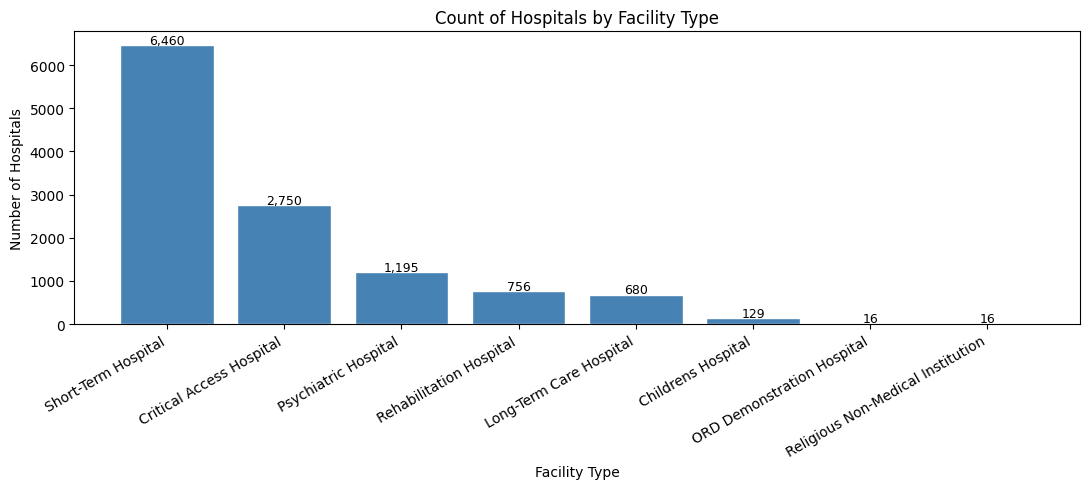

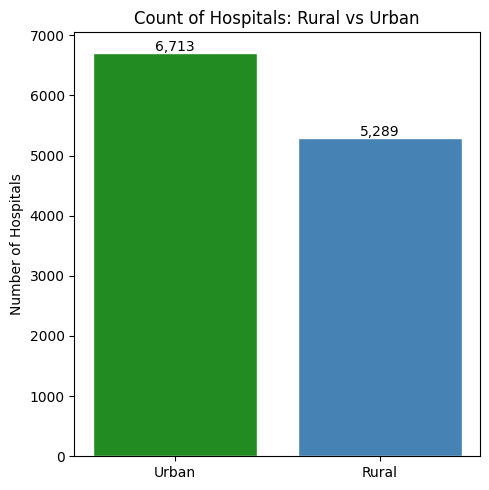

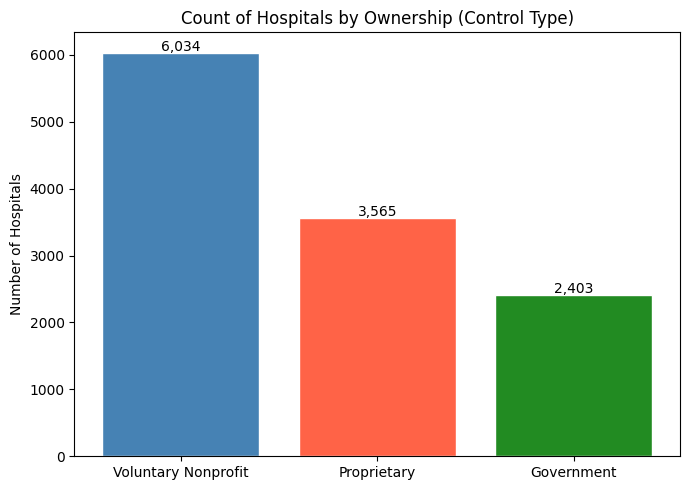

In [15]:
# Facility Type
counts = df_imputed['Facility Type Label'].value_counts()
plt.figure(figsize=(11, 5))
plt.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
plt.title('Count of Hospitals by Facility Type')
plt.xlabel('Facility Type')
plt.ylabel('Number of Hospitals')
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(counts.values):
    plt.text(i, v + 30, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# Rural vs Urban
counts2 = df_imputed['Rural Versus Urban'].value_counts()
labels = {'R': 'Rural', 'U': 'Urban'}
plt.figure(figsize=(5, 5))
plt.bar([labels[k] for k in counts2.index], counts2.values,
        color=['forestgreen', 'steelblue'], edgecolor='white')
plt.title('Count of Hospitals: Rural vs Urban')
plt.ylabel('Number of Hospitals')
for i, v in enumerate(counts2.values):
    plt.text(i, v + 30, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# Control Type
counts3 = df_imputed['Control Type'].value_counts()
plt.figure(figsize=(7, 5))
plt.bar(counts3.index, counts3.values,
        color=['steelblue', 'tomato', 'forestgreen'], edgecolor='white')
plt.title('Count of Hospitals by Ownership (Control Type)')
plt.ylabel('Number of Hospitals')
for i, v in enumerate(counts3.values):
    plt.text(i, v + 30, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

Urban hospitals tend to:

- Have more beds

- Generate higher revenue

- Have larger financial variation

Rural hospitals:

- Smaller bed counts

- Lower financial magnitude

- Tighter clustering

This aligns with real-world expectations about scale and funding differences.

In [16]:
rows = []
for col, div, unit in cols:
    d = df_imputed[col] / div
    rows.append({
        'Column': col,
        'Mean':   round(d.mean(), 2),
        'Median': round(d.median(), 2),
        'Mode':   round(d.mode()[0], 2),
    })

print(pd.DataFrame(rows).to_string(index=False))

                   Column   Mean  Median  Mode
           Number of Beds 133.40   63.00 25.00
               Net Income  11.28    1.30  1.30
              Total Costs 188.22   55.06  3.73
Net Revenue from Medicaid  26.29    9.22  9.22


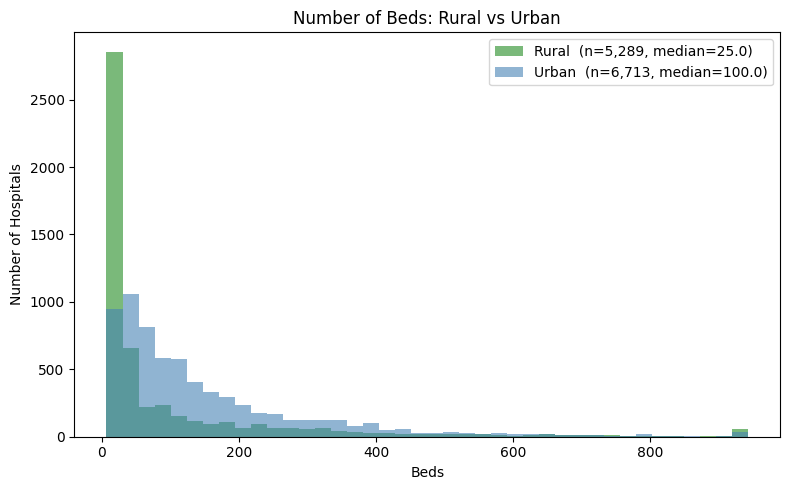

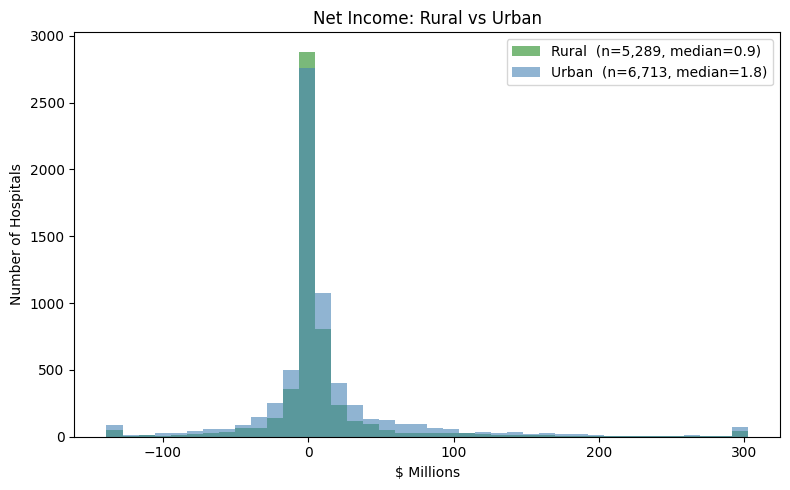

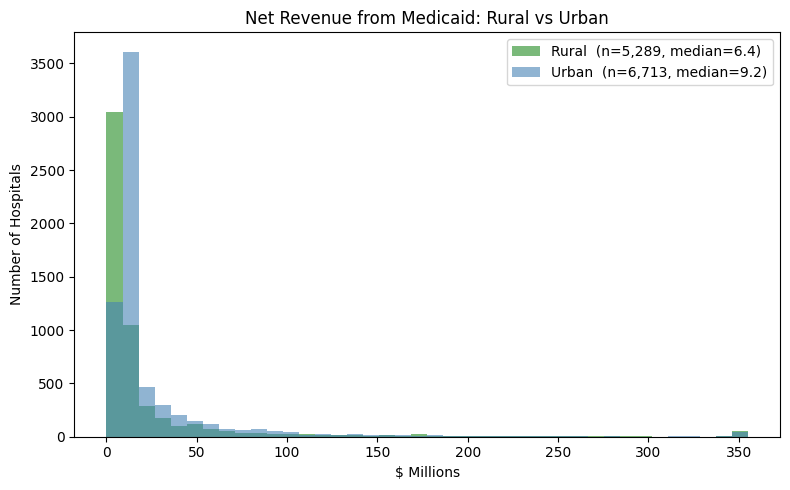

In [17]:
for col, div, unit in [
    ('Number of Beds',             1,    'Beds'),
    ('Net Income',                 1e6,  '$ Millions'),
    ('Net Revenue from Medicaid',  1e6,  '$ Millions'),
]:
    rural = df_imputed[df_imputed['Rural Versus Urban'] == 'R'][col] / div
    urban = df_imputed[df_imputed['Rural Versus Urban'] == 'U'][col] / div

    xlim = (min(rural.quantile(0.01), urban.quantile(0.01)),
            max(rural.quantile(0.99), urban.quantile(0.99)))

    plt.figure(figsize=(8, 5))
    plt.hist(rural.clip(*xlim), bins=40, alpha=0.6, color='forestgreen',
             label=f'Rural  (n={len(rural):,}, median={rural.median():.1f})')
    plt.hist(urban.clip(*xlim), bins=40, alpha=0.6, color='steelblue',
             label=f'Urban  (n={len(urban):,}, median={urban.median():.1f})')
    plt.title(f'{col}: Rural vs Urban')
    plt.xlabel(unit)
    plt.ylabel('Number of Hospitals')
    plt.legend()
    plt.tight_layout()
    plt.show()



**Although rural hospitals appear more concentrated in the smallest bed categories, urban hospitals are more numerous overall and significantly larger on average, with a median of 100 beds compared to 25 beds for rural hospitals.**

In [21]:
ct = pd.crosstab(df_imputed['Facility Type Label'], df_imputed['Rural Versus Urban'])
ct.columns = ['Rural', 'Urban']
ct['Total'] = ct['Rural'] + ct['Urban']
ct['Rural %'] = (ct['Rural'] / ct['Total'] * 100).round(1)
ct['Urban %'] = (ct['Urban'] / ct['Total'] * 100).round(1)
ct = ct.sort_values('Rural %', ascending=False)
ct

,Rural,Urban,Total,Rural %,Urban %
Facility Type Label,,,,,
Critical Access Hospital,2537,213,2750,92.3,7.7
Short-Term Hospital,2571,3889,6460,39.8,60.2
Psychiatric Hospital,124,1071,1195,10.4,89.6
Long-Term Care Hospital,33,647,680,4.9,95.1
Rehabilitation Hospital,24,732,756,3.2,96.8
Childrens Hospital,0,129,129,0.0,100.0
ORD Demonstration Hospital,0,16,16,0.0,100.0
Religious Non-Medical Institution,0,16,16,0.0,100.0


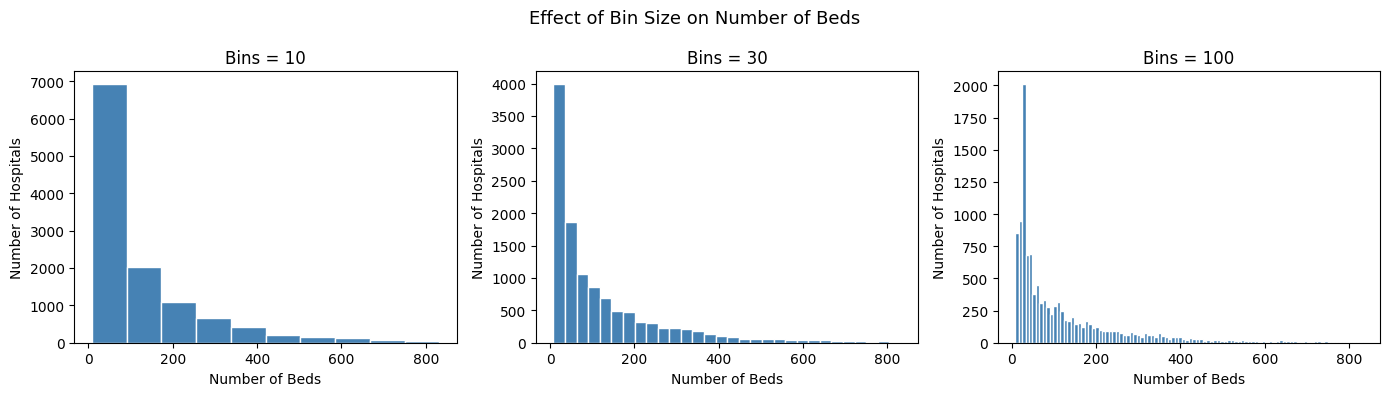

In [ ]:
beds = df_imputed['Number of Beds']
p1, p99 = beds.quantile(0.01), beds.quantile(0.99)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, bins in zip(axes, [10, 30, 100]):
    ax.hist(beds, bins=bins, range=(p1, p99), color='steelblue', edgecolor='white')
    ax.set_title(f'Bins = {bins}')
    ax.set_xlabel('Number of Beds')
    ax.set_ylabel('Number of Hospitals')
plt.suptitle('Effect of Bin Size on Number of Beds', fontsize=13)
plt.tight_layout()
plt.show()

**30 bins is the best number for best destribution**

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

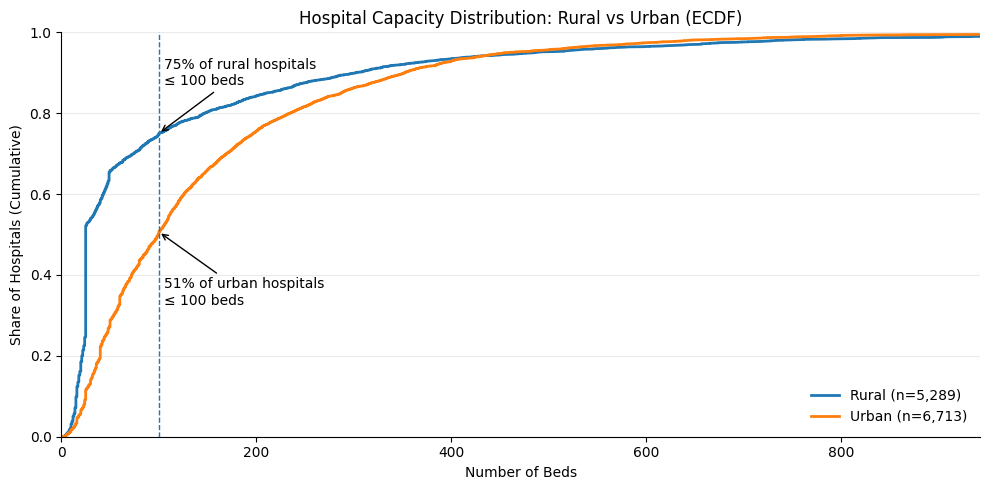

In [22]:
import numpy as np
import matplotlib.pyplot as plt

beds_col = "Number of Beds"
group_col = "Rural Versus Urban"   

rural_beds = df_imputed.loc[df_imputed[group_col] == "R", beds_col].dropna().astype(float).values
urban_beds = df_imputed.loc[df_imputed[group_col] == "U", beds_col].dropna().astype(float).values

def ecdf(x):
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

xr, yr = ecdf(rural_beds)
xu, yu = ecdf(urban_beds)

xmax = max(np.quantile(rural_beds, 0.99), np.quantile(urban_beds, 0.99))

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(xr, yr, linewidth=2, label=f"Rural (n={len(rural_beds):,})")
ax.plot(xu, yu, linewidth=2, label=f"Urban (n={len(urban_beds):,})")

ax.set_xlim(0, xmax)
ax.set_ylim(0, 1)

ax.set_title("Hospital Capacity Distribution: Rural vs Urban (ECDF)")
ax.set_xlabel("Number of Beds")
ax.set_ylabel("Share of Hospitals (Cumulative)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="y", alpha=0.25)

threshold = 100 

pct_rural = (rural_beds <= threshold).mean()
pct_urban = (urban_beds <= threshold).mean()

ax.axvline(threshold, linestyle="--", linewidth=1)

ax.annotate(
    f"{pct_rural:.0%} of rural hospitals\n≤ {threshold} beds",
    xy=(threshold, pct_rural),
    xytext=(threshold * 1.05, min(0.98, pct_rural + 0.12)),
    arrowprops=dict(arrowstyle="->", lw=1),
    fontsize=10
)

ax.annotate(
    f"{pct_urban:.0%} of urban hospitals\n≤ {threshold} beds",
    xy=(threshold, pct_urban),
    xytext=(threshold * 1.05, max(0.02, pct_urban - 0.18)),
    arrowprops=dict(arrowstyle="->", lw=1),
    fontsize=10
)

ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**This graph is an empirical cumulative distribution function (ECDF), which displays the cumulative share of hospitals at or below each bed count. The x-axis represents the number of beds, and the y-axis represents the cumulative proportion of hospitals with that many beds or fewer. By comparing the rural and urban curves, the graph communicates how hospital capacity is distributed across the two groups. The rural curve rises much more steeply at lower bed counts, indicating that rural hospitals are heavily concentrated among smaller facilities. For example, 75% of rural hospitals have 100 beds or fewer, compared to 51% of urban hospitals. In contrast, the urban curve increases more gradually, reflecting a wider distribution that includes many medium and large hospitals.**